In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [7]:
metadata = pd.read_csv(
    "interpretable_profiles.csv", index_col="player_id"
)
final_profiles = pd.read_csv("profiles_scaled.csv")

final_profiles.index = metadata.index

In [8]:
cosine_sim_matrix = cosine_similarity(final_profiles)

cosine_sim_df = pd.DataFrame(
    cosine_sim_matrix, index=metadata["player"], columns=metadata["player"]
)

print("Cosine Similarity Matrix Created")

Cosine Similarity Matrix Created


In [9]:
euclidean_matrix = euclidean_distances(final_profiles)

euclidean_df = pd.DataFrame(
    euclidean_matrix, index=metadata["player"], columns=metadata["player"]
)

print("Euclidean Distance Matrix Created")

Euclidean Distance Matrix Created


In [10]:
nn_model = NearestNeighbors(n_neighbors=6, metric="cosine")

nn_model.fit(final_profiles)

print("Nearest Neighbors Model Ready")

Nearest Neighbors Model Ready


In [ ]:
def compare_similar_players(
    player_name, profiles_df, scaled_features, nn_model, cosine_df, euclidean_df
):
    if player_name not in profiles_df["player"].values:
        raise ValueError(f"Player '{player_name}' not found in the profiles.")

    player_idx = profiles_df[profiles_df["player"] == player_name].index[0]

    target_features = scaled_features.loc[player_idx].values.reshape(1, -1)
    distances, indices = nn_model.kneighbors(target_features)

    comparison_list = []

    for idx in indices.flatten()[1:]:
        similar_player_name = profiles_df.iloc[idx]["player"]

        cos_sim = cosine_df.loc[player_name, similar_player_name]
        eucl_dist = euclidean_df.loc[player_name, similar_player_name]

        comparison_list.append(
            {
                "Target Player": player_name,
                "Compared Player": similar_player_name,
                "Cosine Similarity": round(cos_sim, 4),
                "Euclidean Distance": round(eucl_dist, 4),
            }
        )

    return pd.DataFrame(comparison_list)

In [48]:
def search_player(df, name):
    return df[df["player"].str.contains(name, case=False, na=False)]

search_player(metadata, "salah")

,player,team,position,position_group,nationality,total_minutes,matches_played,avg_minutes_per_match,pass_completion,avg_pass_length,...,cross_quality_index,shot_quality_index,block_quality_index,pass_creativity_index,set_piece_delivery_index,dribble_composite,duel_composite,discipline_score,pos_FWD,pos_MID
player_id,,,,,,,,,,,,,,,,,,,,,
3531.0,Mohamed Salah,AS Roma,Right Wing,FWD,Egypt,3296,40,82.4,0.792288,14.400364,...,0.745449,1.611044,0.081917,2.361954,0.600728,2.553095,2.607706,3.522451,1,0
282381.0,Ibrahim Salah,Rennes,Right Wing,FWD,Morocco,90,1,90.0,0.750000,18.288412,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1,0
388167.0,Mohamed Ilyes Salah Chaïbi,AS Monaco,Left Wing,FWD,Algeria,90,1,90.0,1.000000,11.654035,...,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,1.000000,0.500000,1,0


In [49]:
comparison_df = compare_similar_players(
    player_name="Leroy Sané",
    profiles_df=metadata,
    scaled_features=final_profiles,
    nn_model=nn_model,
    cosine_df=cosine_sim_df,
    euclidean_df=euclidean_df,
)

comparison_df

c:\Users\amrta\.conda\envs\datascience\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,Target Player,Compared Player,Cosine Similarity,Euclidean Distance
0,Leroy Sané,Yannick Ferreira Carrasco,0.9716,5.3516
1,Leroy Sané,José Luis Morales Nogales,0.9676,5.6768
2,Leroy Sané,Raheem Sterling,0.9642,5.9613
3,Leroy Sané,Ayoze Pérez Gutiérrez,0.9641,8.6667
4,Leroy Sané,Emma Follis,0.9624,11.8292


In [26]:
def plot_player_comparison(p1, p2, features, df, X_scaled):
    idx1 = df[df["player"] == p1].index[0]
    idx2 = df[df["player"] == p2].index[0]

    stats1 = X_scaled.loc[idx1, features].values
    stats2 = X_scaled.loc[idx2, features].values

    stats1 = np.append(stats1, stats1[0])
    stats2 = np.append(stats2, stats2[0])

    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False)
    angles = np.append(angles, angles[0])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    clean_features = [f.replace("_", " ").title() for f in features]
    plt.xticks(angles[:-1], clean_features, color="grey", size=10)

    ax.plot(angles, stats1, "b-", linewidth=2, label=p1)
    ax.fill(angles, stats1, "b", alpha=0.1)

    ax.plot(angles, stats2, "r-", linewidth=2, label=p2)
    ax.fill(angles, stats2, "r", alpha=0.1)

    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))
    plt.title(f"Style Comparison: {p1} vs {p2}", size=14, y=1.1)
    plt.show()

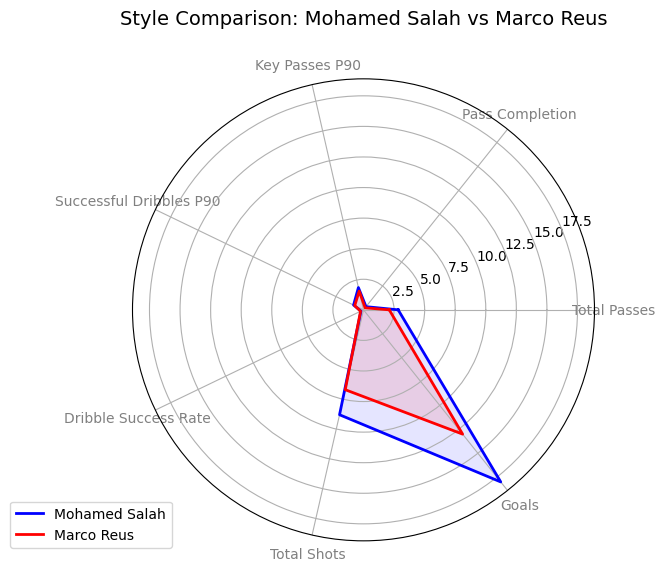

In [52]:
soccer_features = [
    "total_passes",
    "pass_completion",
    "key_passes_p90",
    "successful_dribbles_p90",
    "dribble_success_rate",
    "total_shots",
    "goals",
]

plot_player_comparison(
    "Mohamed Salah",
    "Marco Reus",
    soccer_features,
    metadata,
    final_profiles,
)

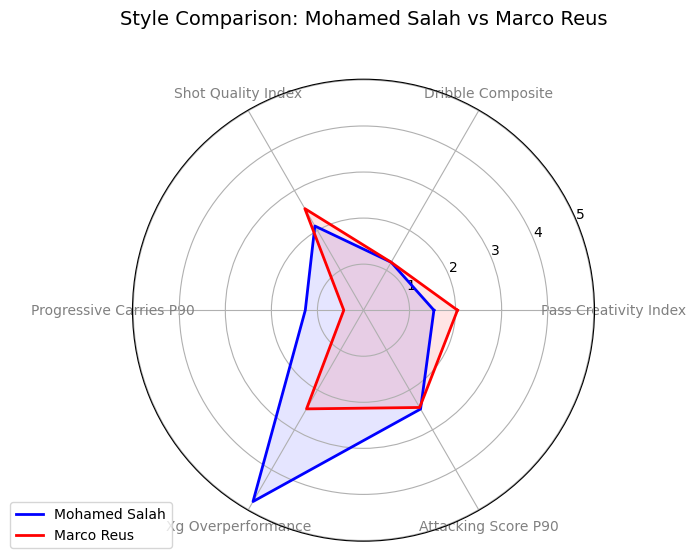

In [56]:
soccer_features = [
    "pass_creativity_index",
    "dribble_composite",
    "shot_quality_index", 
    "progressive_carries_p90",
    "xg_overperformance",
    "attacking_score_p90",
]
plot_player_comparison(
    "Mohamed Salah",
    "Marco Reus",
    soccer_features,
    metadata,
    final_profiles,
)